# Insurance Cost Analysis #

### Task 1 : Import the dataset ###

In [207]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\bhati\Downloads\archive (6)\Medical_insurance.csv",header=None)

In [208]:
print(df.head(10))

     0       1       2         3       4          5            6
0  age     sex     bmi  children  smoker     region      charges
1   19  female    27.9         0     yes  southwest    16884.924
2   18    male   33.77         1      no  southeast    1725.5523
3   28    male      33         3      no  southeast     4449.462
4   33    male  22.705         0      no  northwest  21984.47061
5   32    male   28.88         0      no  northwest    3866.8552
6   31  female   25.74         0      no  southeast    3756.6216
7   46  female   33.44         1      no  southeast    8240.5896
8   37  female   27.74         3      no  northwest    7281.5056
9   37    male   29.83         2      no  northeast    6406.4107


Add the headers to the dataframe, as mentioned in the project scenario.

In [210]:
headers=["age","gender","bmi","no_of_children","smoker","region","charges"]
df.columns= headers

Now, replace the '?' entries with 'NaN' values.

In [212]:
df.replace('?',np.nan,inplace=True)

# Task 2 : Data Wrangling

In [214]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2773 entries, 0 to 2772
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             2773 non-null   object
 1   gender          2773 non-null   object
 2   bmi             2773 non-null   object
 3   no_of_children  2773 non-null   object
 4   smoker          2773 non-null   object
 5   region          2773 non-null   object
 6   charges         2773 non-null   object
dtypes: object(7)
memory usage: 151.8+ KB
None


Handle missing data:

For continuous attributes (e.g., age), replace missing values with the mean.
For categorical attributes (e.g., smoker), replace missing values with the most frequent value.
Update the data types of the respective columns.
Verify the update using df.info().


In [216]:
#Converted age datatype to int64 and replace nan with mean
# age is a continuous variable, replace with mean age

df = df[df["age"] != "age"]
df["age"] = pd.to_numeric(df["age"], errors="coerce")

df["age"] = df["age"].fillna(df["age"].mean())
print(df["age"].dtype)        # should be float64
print(df["age"].isna().sum()) # should be 0

int64
0


C:\Users\bhati\AppData\Local\Temp\ipykernel_22204\2878546341.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age"] = pd.to_numeric(df["age"], errors="coerce")
C:\Users\bhati\AppData\Local\Temp\ipykernel_22204\2878546341.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age"] = df["age"].fillna(df["age"].mean())


In [217]:
# smoker is a categorical attribute, replace with most frequent entry
is_smoker = df['smoker'].value_counts().idxmax()
df["smoker"].replace(np.nan, is_smoker)
print(df["smoker"].unique())

['yes' 'no']


Also note, that the charges column has values which are more than 2 decimal places long. Update the charges column such that all values are rounded to nearest 2 decimal places. Verify conversion by printing the first 5 values of the updated dataframe.

In [219]:
#First convert dt of charge to float
df["charges"]=pd.to_numeric(df["charges"],errors="coerce")

# now round off till 2 decimal places
df["charges"]=df["charges"].round(2)
print(df["charges"].head(5))

1    16884.92
2     1725.55
3     4449.46
4    21984.47
5     3866.86
Name: charges, dtype: float64


C:\Users\bhati\AppData\Local\Temp\ipykernel_22204\1914839599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["charges"]=pd.to_numeric(df["charges"],errors="coerce")
C:\Users\bhati\AppData\Local\Temp\ipykernel_22204\1914839599.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["charges"]=df["charges"].round(2)


# Task 3 : Exploratory Data Analysis (EDA)

Implement the regression plot for `charges` with respect to `bmi`. 

UFuncTypeError: ufunc 'multiply' did not contain a loop with signature matching types (dtype('<U5'), dtype('float64')) -> None

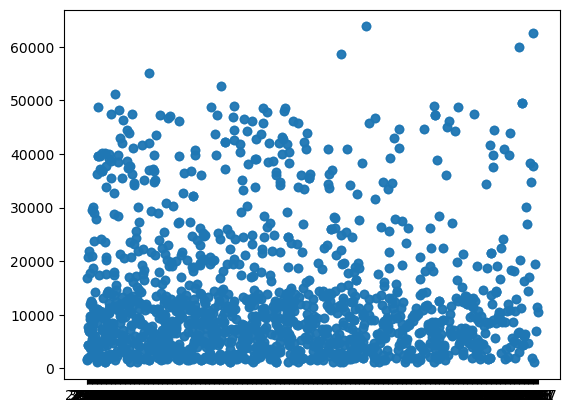

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.regplot(x="bmi",y="charges",data=df,line_kws={"color": "red"})

plt.ylim(0,)
plt.show()

Implement the box plot for charges with respect to smoker.

<Axes: xlabel='smoker', ylabel='charges'>

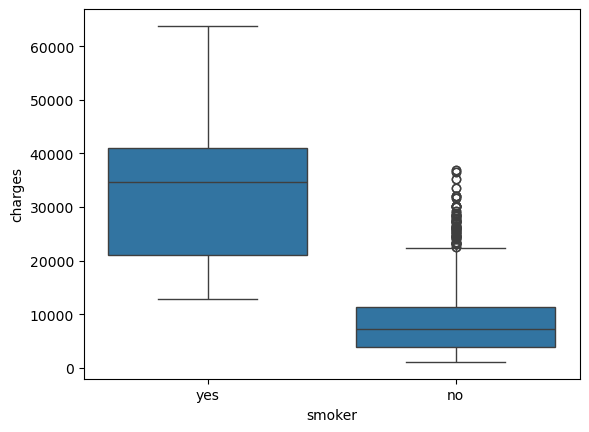

In [228]:
sns.boxplot(x="smoker",y="charges",data=df)

Print the correlation matrix for the dataset.

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
print(numeric_df.corr())

# Task 4 : Model Development

Fit a linear regression model that may be used to predict the `charges` value, just by using the `smoker` attribute of the dataset. Print the $ R^2 $ score of this model.

In [236]:
from sklearn.linear_model import LinearRegression
lm=LinearRegression()
#df["smoker"] = df["smoker"].astype(str).str.strip().str.lower()
#as smoker is categorical data,we need to convert it into numeric form to fit it in linear regression

print(df["smoker"].isna().sum())
print(df["smoker"].unique())
# normalize text
df["smoker"] = df["smoker"].astype(str).str.strip().str.lower() 
# fill anything still missing
df["smoker"] = df["smoker"].fillna(df["smoker"].mode().iloc[0])
# map categories
df["smoker"] = df["smoker"].replace({"yes": 1, "no": 0})#as smoker is categorical data,we need to convert it into numeric form to fit it in linear regression
print(df["smoker"].isna().sum())   # MUST be 0
print(df["smoker"].unique())      # MUST be [0 1]
print(df["smoker"].dtype)         # int or float

0
['yes' 'no']
0
[1 0]
int64


C:\Users\bhati\AppData\Local\Temp\ipykernel_22204\1469872345.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["smoker"] = df["smoker"].astype(str).str.strip().str.lower()
C:\Users\bhati\AppData\Local\Temp\ipykernel_22204\1469872345.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["smoker"] = df["smoker"].fillna(df["smoker"].mode().iloc[0])
C:\Users\bhati\AppData\Local\Temp\ipykernel_22204\1469872345.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a 

In [245]:
x = df[["smoker"]]    # 2D
y = df["charges"]     # 1D

#lm = LinearRegression()
lm.fit(x, y)

LinearRegression()

In [251]:
print("R² score:", lm.score(x, y))
print("Coefficient:", lm.coef_)
print("Intercept:", lm.intercept_)

R² score: 0.6221791733924185
Coefficient: [23805.26542958]
Intercept: 8417.874393115952


Fit a linear regression model that may be used to predict the `charges` value, just by using all other attributes of the dataset. Print the $ R^2 $ score of this model. You should see an improvement in the performance.

In [301]:
df_encoded = pd.get_dummies(
    df,
    columns=["region", "gender"],
    drop_first=True
)
print(df_encoded.columns)

Index(['age', 'bmi', 'no_of_children', 'smoker', 'charges', 'region_northwest',
       'region_southeast', 'region_southwest', 'gender_1'],
      dtype='object')


In [303]:
z = df_encoded[[
    "age",
    "bmi",
    "no_of_children",
    "smoker",
    "gender_1",          
    "region_northwest",
    "region_southeast",
    "region_southwest"
]]

y = df_encoded["charges"]
lm.fit(z,y)

LinearRegression()

In [311]:
print("R2 Score:",lm.score(z,y))
print("Coefficient:",lm.coef_)
print("Intercept:", lm.intercept_)

R2 Score: 0.7509331529861025
Coefficient: [  255.57686075   330.01530029   506.34261264 23976.1971597
   -56.94351903  -331.84113489 -1078.36197093 -1055.25367409]
Intercept: -11635.451327266845


Create a training pipeline that uses `StandardScaler()`, `PolynomialFeatures()` and `LinearRegression()` to create a model that can predict the `charges` value using all the other attributes of the dataset. There should be even further improvement in the performance.


In [345]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

Input=[('scale',StandardScaler()),('polynomial',PolynomialFeatures(include_bias=False)),('model',LinearRegression())]
pipe=Pipeline(Input)
z=z.astype(float)
pipe.fit(z,y)
ypipe=pipe.predict(z)
print("R2 Score:",pipe.score(z,y))

R2 Score: 0.8465264927227687


# Task 5 : Model Refinement

Split the data into training and testing subsets, assuming that 20% of the data will be reserved for testing.


In [351]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(z,y,test_size=0.2,random_state=1)

Initialize a Ridge regressor that used hyperparameter $ \alpha = 0.1 $. Fit the model using training data data subset. Print the $ R^2 $ score for the testing data.

In [358]:
from sklearn.linear_model import Ridge
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(z,y)
Yhat=RidgeModel.predict(z)
print("R2 Score:",RidgeModel.score(z,y))

R2 Score: 0.7509331209699354



Apply polynomial transformation to the training parameters with degree=2. Use this transformed feature set to fit the same regression model, as above, using the training subset. Print the 
 score for the testing subset.

In [365]:
from sklearn.preprocessing import PolynomialFeatures
pr=PolynomialFeatures(degree=2,include_bias=False)
x_train_pr=pr.fit_transform(x_train)
x_test_pr=pr.transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print("R2 Score:",(y_test, y_hat))

R2 Score: (2123    40419.02
1894     3077.10
2318     6238.30
1761     1391.53
731     19362.00
          ...   
195      1137.47
988     28340.19
1147    52590.83
2735     3238.44
639     20149.32
Name: charges, Length: 555, dtype: float64, array([41189.33593731,  4788.33128193,  7283.69663543,  2258.78350307,
       21601.25713166,  4359.30262299, 26234.4053703 ,  3071.89406968,
        3871.78443903, 13433.07044734,  5232.72882655,  9519.589389  ,
       10711.30531015, 21294.75721755, 10522.19928089,  4466.72877136,
       12706.57695212,  4325.50982312, 12496.43852104, 11819.192736  ,
        5744.60064537,  6578.1937067 ,  1339.89350587, 48075.79613062,
       20269.43027437,  9662.87417034, 51336.16995082,  6952.11746948,
       12606.24503824, 28868.81072257, 12789.70169362, 12865.17856851,
       30938.23769882,  5977.59782925,  4327.31780491, 13550.10552139,
        4479.84923623, 14283.31595105, 11004.9352212 , 12259.80713657,
       14272.10649334, 11178.75136143, 14780.557